In [2]:
import matplotlib.pyplot as plt
import numpy as np
import  scipy.stats

In [3]:
#at home

mu = 10           
sigma = 2         
n = 30    
N_trials = 1000

means = []
stds = []

for _ in range(N_trials):
    sample = np.random.normal(mu, sigma, n)
    x_bar = np.mean(sample)
    s = np.std(sample, ddof=1)
    means.append(x_bar)
    stds.append(s)

means = np.array(means)
stds = np.array(stds)

mean_of_means = np.mean(means)
std_of_means = np.std(means, ddof=1)  

mean_of_stds = np.mean(stds)
std_of_stds = np.std(stds, ddof=1)  

# Theoretical
error_mean_theory = sigma / np.sqrt(n)

error_s_teorico_alt = (1 / np.sqrt(2)) * np.sqrt(n / (n - 1)) * error_mean_theory

#lets see if they agre
print(f" Results for {N_trials} realizations with samples size of n = {n} \n")
print(f"Median of x̄: {mean_of_means:.4f}")
print(f"Error of x̄: {std_of_means:.4f}")
print(f"Theoretical Error of x̄:  {error_mean_theory:.4f}\n")

print(f"Mean of s: {mean_of_stds:.4f}")
print(f"Error of s: {std_of_stds:.4f}")
print(f"Theoretical Error of s:: {error_s_teorico_alt:.4f}")


 Results for 1000 realizations with samples size of n = 30 

Median of x̄: 9.9961
Error of x̄: 0.3672
Theoretical Error of x̄:  0.3651

Mean of s: 1.9656
Error of s: 0.2612
Theoretical Error of s:: 0.2626


In [4]:
#about the horses

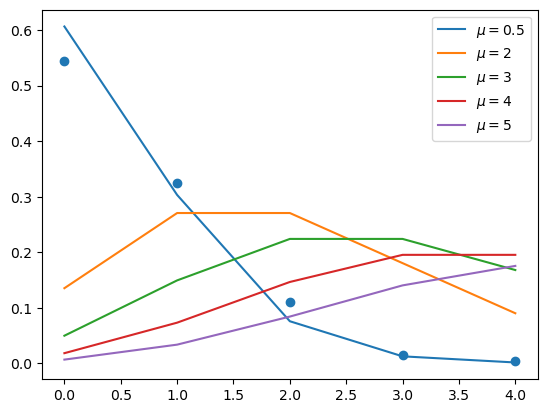

In [5]:
events=[0,1,2,3,4]
data=np.array([109,65,22,3,1])
data=data/sum(data)

plt.scatter(events, data) #i think can be a poissionan dist actually, since is number of events changing with corpy

for u in [0.5,2,3,4,5]:
    Po=scipy.stats.poisson(u).pmf(events)
    plt.plot(events,Po,label='$\mu='+str(u)+"$")
plt.legend();


In [6]:
##Theoretically if you want a good poisson dist, so the mean should be equal to mu, so, what if the mean is mu??

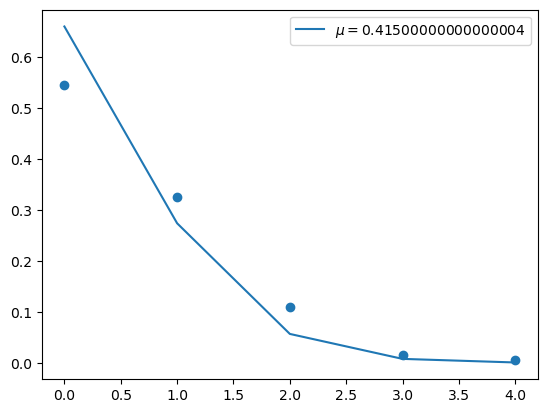

In [7]:
mu_real=np.average(data, weights=data)
plt.scatter(events, data)
Po=scipy.stats.poisson(mu_real).pmf(events)
plt.plot(events,Po,label='$\mu='+str(mu_real)+"$")
plt.legend()

#here i just plot the possionan dist with a median equal ot the mena of the data, seems to be a possionan.

In [8]:
##Not the ebst actually. but lets do the nasty integral

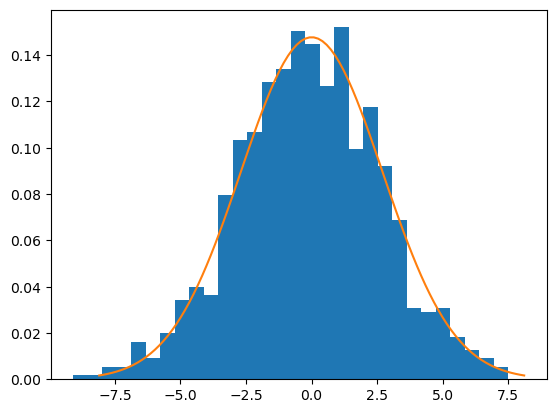

In [9]:
sigma=2.7
N=1000

gauss = scipy.stats.norm(loc=0,scale=sigma)
x=gauss.rvs(N)

plt.hist(x, bins=30, density=True);
plt.plot(np.linspace(-3*sigma,3*sigma,100), gauss.pdf(np.linspace(-3*sigma,3*sigma,100)))

In [10]:
sampling=np.abs(gauss.rvs(N)) #just sampling from 0 to in inf
I=np.mean(sampling**3) * (2/np.pi)**(-1/2) * sigma
I_real= 2*sigma**4
print(f"The integral estimated using the Monte Carlo method is: {I:.5f}")
print(f"The analytical value of the integral is: {I_real:.5f}")
print(f"The relative error is: {100 * np.abs((I_real - I) / I_real):.3f}%")

The integral estimated using the Monte Carlo method is: 107.75786
The analytical value of the integral is: 106.28820
The relative error is: 1.383%


[]

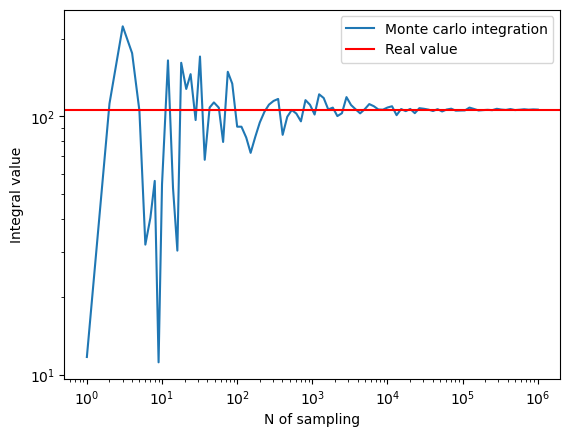

In [11]:
def funcion(sigma, N):
    gauss = scipy.stats.norm(loc=0,scale=sigma)
    sampling=np.abs(gauss.rvs(N))
    return np.mean(sampling**3) * (2/np.pi)**(-1/2) * sigma

def knownresult(sigma):
    return 2*sigma**4

N=np.unique(np.logspace(0,6,100,dtype=int))
attemps=[funcion(sigma, Nval) for Nval in N]
plt.plot(N,attemps, label='Monte carlo integration')
plt.axhline(knownresult(sigma),color="r", label='Real value')
plt.xlabel('N of sampling')
plt.ylabel('Integral value')
plt.legend()
plt.loglog()

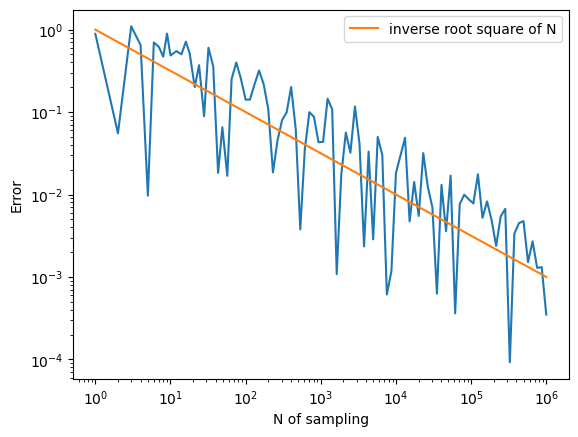

In [12]:
error= np.abs((np.array(attemps)-knownresult(sigma))/knownresult(sigma))

plt.plot(N, error)
plt.plot(N, N**-0.5, label='inverse root square of N')
plt.loglog()
plt.xlabel('N of sampling')
plt.ylabel('Error')
plt.legend();

In [13]:
#lets do i N tines
N= 1000 #samplings
N_2 = 10000 #times
integral=[]
for i in range(N_2):
    x=funcion(sigma,N)
    integral.append(x)


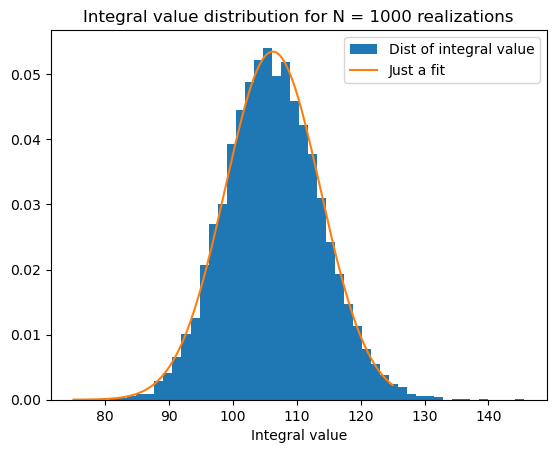

In [14]:
plt.hist(integral, density=True, bins=50, label='Dist of integral value'); #seems to be a gaussian, lets just fir with a gaussian.
mean = np.average(integral)
sigma = np.std(integral)
gauss2 = scipy.stats.norm(loc=mean,scale=sigma)
x = np.linspace(75,125,1000)
plt.plot(x,gauss2.pdf(x), label='Just a fit')
plt.xlabel('Integral value')
plt.title(f'Integral value distribution for N = {N} realizations')
plt.legend();

In [15]:
#put your hands dirty 4

In [16]:
from astroML.datasets import fetch_dr7_quasar
import astropy

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:10000]

z = data['redshift']

astropy.cosmology.Planck18

FlatLambdaCDM(name="Planck18", H0=67.66 km / (Mpc s), Om0=0.30966, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.04897)

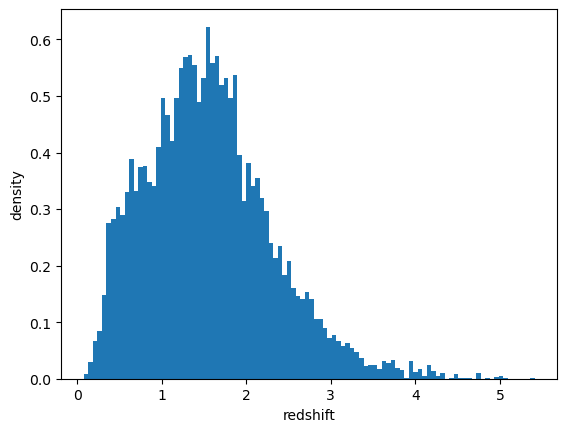

In [17]:
plt.hist(z,bins=100, density=True)
plt.ylabel("density")
plt.xlabel("redshift");

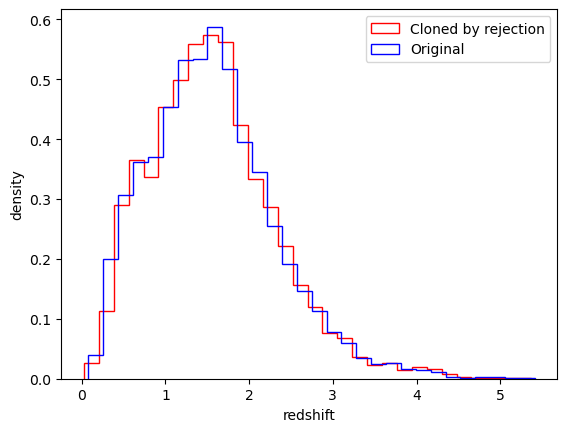

In [18]:
counts, bins = np.histogram(z, bins=100, density=True)

N=10000
good_x=[]
good_y=[]

while len(good_x) < N:
    x=np.random.uniform(0,bins.max())
    y=np.random.uniform(0,counts.max())
    idx = np.searchsorted(bins, x)-1
    if y < counts[idx]:
        good_x.append(x)
        good_y.append(y)

plt.hist(good_x,bins=30, density=True, histtype='step', color='r', label='Cloned by rejection')
plt.hist(z,bins=30, density=True, histtype='step', color='b', label='Original')
plt.ylabel("density")
plt.xlabel("redshift")
plt.legend();

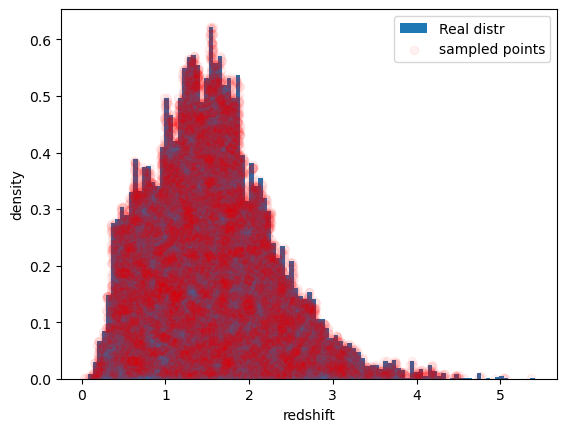

In [22]:
plt.hist(z,bins=100, density=True, label='Real distr')
plt.scatter(good_x, good_y, color='r', alpha=0.05, label='sampled points')
plt.legend()
plt.ylabel("density")
plt.xlabel("redshift");

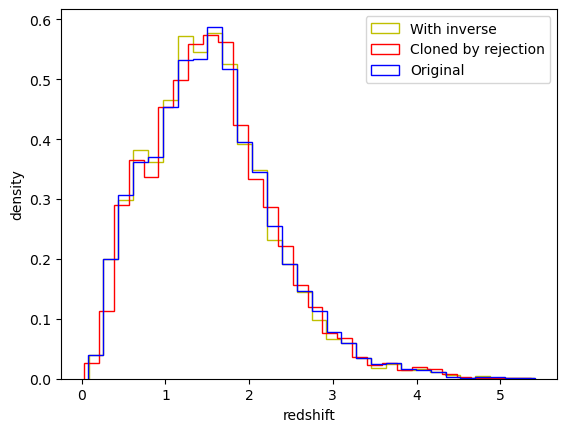

In [23]:
# acommualtive function xd 

u=np.random.uniform(0,1,N)
disth = scipy.stats.rv_histogram((counts,bins))
y=disth.ppf(u)
plt.hist(y,bins=30,density=True,histtype='step',color='y',label='With inverse')
plt.hist(good_x,bins=30, density=True, histtype='step', color='r', label='Cloned by rejection')
plt.hist(z,bins=30, density=True, histtype='step', color='b', label='Original')
plt.ylabel("density")
plt.xlabel("redshift")
plt.legend();

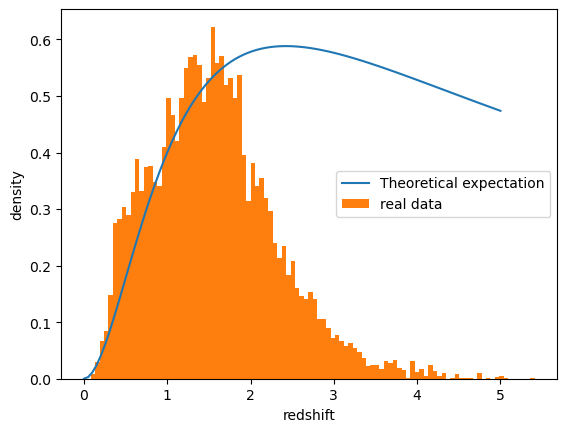

In [24]:
z_vals = np.linspace(0,5,100)
comvol = astropy.cosmology.Planck18.differential_comoving_volume(z_vals).value 

plt.plot(z_vals, comvol/(1.7*comvol.max()), label="Theoretical expectation")
plt.hist(z, bins=100, density=True, label="real data")
plt.legend()
plt.ylabel("density")
plt.xlabel("redshift");

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


The maximun of the likehood is located at 0.81481, and the MLE is 0.81567


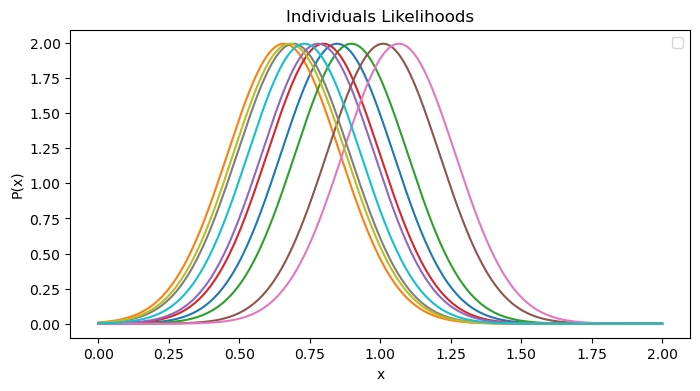

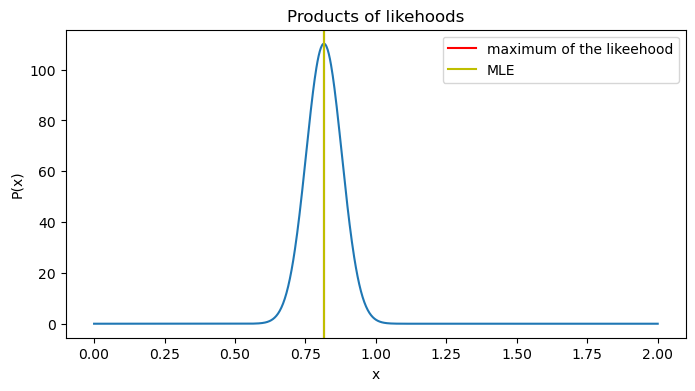

In [27]:
#5 first point

sigma=0.2
N=10
measurements = np.random.normal(loc=1, scale=sigma, size=N)

x_grid = np.linspace(1 - 5 * sigma, 1 + 5 * sigma, 1000)

likelihoods = np.array([scipy.stats.norm.pdf(x_grid, loc=m, scale=sigma) for m in measurements])

plt.figure(figsize=(8, 4))
[plt.plot(x_grid, m) for m in likelihoods]
plt.title("Individuals Likelihoods")
plt.xlabel("x")
plt.ylabel("P(x)")
plt.legend()

product=np.prod(likelihoods, axis=0)

plt.figure(figsize=(8, 4))
plt.plot(x_grid,product)
plt.axvline(x_grid[np.argmax(product)], color='r', label='maximum of the likeehood')
plt.axvline(np.mean(measurements), color='y', label='MLE')
plt.title("Products of likehoods")
plt.xlabel("x")
plt.ylabel("P(x)")
plt.legend()

print(f"The maximun of the likehood is located at {x_grid[np.argmax(product)]:.5f}, and the MLE is {np.mean(measurements):.5f}")

In [101]:
#second point

In [136]:
diff=np.diff(np.log(product), n=2)
diff_norm = -diff/(x_grid[1]-x_grid[0])**2
sigma_pro =  np.sqrt(1/diff_norm)
sigma_final=np.max(sigma_pro)

print(f"The error of the mean estimate with the fisher matrix is {sigma_final:.5f}")

MLE_sigma=sigma/N**0.5

print(f"The error of the mean is {MLE_sigma:.5f}")

The error of the mean estimate with the fisher matrix is 0.06325
The error of the mean is 0.06325


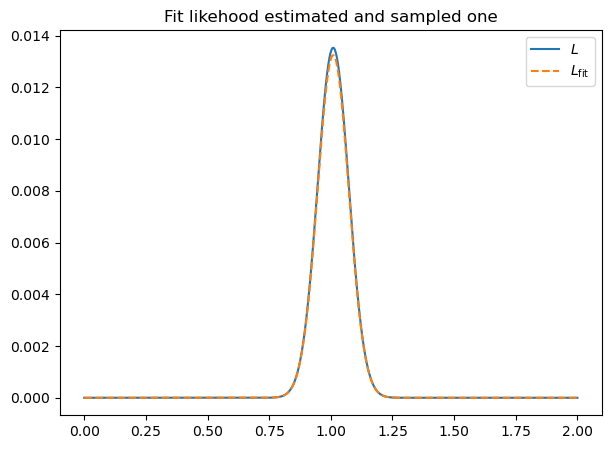

In [149]:
from scipy.stats import norm

Gaussian_2 = norm.pdf(x_grid,loc=np.mean(measurements),scale=MLE_sigma)  

fig, ax = plt.subplots(figsize=(7, 5))

plt.plot(x_grid, product , ls='-', label=r'$L$')

C = 0.0021 #by guess
plt.plot(x_grid, C*Gaussian_2, ls='dashed', label=r'$L_\mathrm{fit}$')

plt.title("Fit likehood estimated and sampled one")
plt.legend()